# 03 · Analyze in batch

An analysis turns measurements into **derived values** — scalars that land in
the same table as the authored parameters, so they can be filtered and plotted
alongside them.

Two ship with the package: 1D peak fitting and particle sizing. Both are
technique-neutral. A chemistry-specific analysis belongs in a package of its
own and registers itself on import.

In [1]:
from pathlib import Path

from NanoOrganizer import open_project
from NanoOrganizer.demo import demo_root

PROJECT = demo_root("DemoProject")

# attach=False: the micrographs were linked in 00 and are in the saved store.
# Re-attaching by folder convention would work here and would be the wrong
# habit — see the note at the top of 00.
wb = open_project(PROJECT, attach=False)
print(wb.summary())


DemoProject: 6 samples, 12 measurements (12 readable here, 0 not mounted).
Modalities: uvvis, tem
Root: ../../../OrgDemo/DemoProject


## One sample first

Always look at a single result before batching. `AnalysisResult` keeps three
things apart on purpose: `values` (stored), `curves` (for plotting, never
stored) and `diagnostics` (what the numbers depend on).

In [2]:
result = wb.run("peak_fit", "Sample000001")
print("ok:", result.ok, "|", result.message or "no warnings")
for name, value in result.values.items():
    error = result.errors.get(name)
    print(f"  {name:20s} {value:10.4f}" + (f"  ± {error:.4f}" if error else ""))

ok: True | no warnings
  baseline                 0.1120  ± 0.0009
  peak1_amplitude          0.9622  ± 0.0034
  peak1_center           499.7160  ± 0.1159
  peak1_width             28.6551  ± 0.1223
  fit_r2                   0.9942


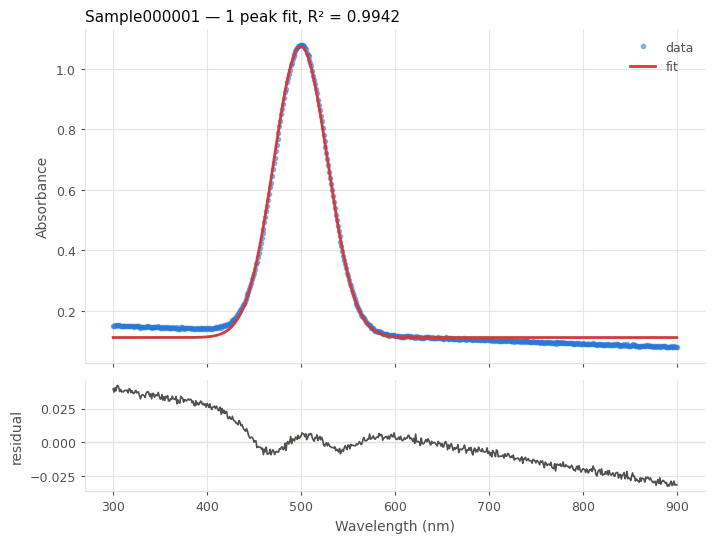

In [3]:
import matplotlib.pyplot as plt
from NanoOrganizer.viz import plots

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})
plots.plot_peak_fit(result, ax=axes)
plt.show()

## Every sample

`batch` writes the scalars back onto each sample and returns one row per
measurement — **including the failures**, with the reason. A batch that
silently skips its failures is worse than no batch.

In [4]:
frame = wb.batch("peak_fit")
frame[["sample_id", "peak1_center", "peak1_center_err", "peak1_width",
       "fit_r2", "ok"]]

peak_fit: 6/6 succeeded


,sample_id,peak1_center,peak1_center_err,peak1_width,fit_r2,ok
measurement_id,,,,,,
Sample000001:uvvis:synthesis-spectra,Sample000001,499.716048,0.115879,28.655082,0.994160,True
Sample000002:uvvis:synthesis-spectra,Sample000002,505.714693,0.117598,28.648442,0.993984,True
Sample000003:uvvis:synthesis-spectra,Sample000003,511.699996,0.117869,28.599090,0.993938,True
Sample000004:uvvis:synthesis-spectra,Sample000004,517.721673,0.118254,28.566164,0.993886,True
Sample000005:uvvis:synthesis-spectra,Sample000005,523.710406,0.119651,28.506722,0.993718,True
Sample000006:uvvis:synthesis-spectra,Sample000006,529.714464,0.120074,28.473050,0.993660,True


## Particle sizing

In [5]:
sizes = wb.batch("particle_sizing")
sizes[["sample_id", "d_mean", "d_median", "d_std", "n_particles", "ok"]]

particle_sizing: 6/6 succeeded


,sample_id,d_mean,d_median,d_std,n_particles,ok
measurement_id,,,,,,
Sample000001:tem:characterization,Sample000001,8.153054,8.185605,1.001982,108,True
Sample000002:tem:characterization,Sample000002,9.714106,9.557978,1.184251,75,True
Sample000003:tem:characterization,Sample000003,11.109315,11.134686,1.458684,48,True
Sample000004:tem:characterization,Sample000004,12.228006,12.054394,1.533644,48,True
Sample000005:tem:characterization,Sample000005,13.536350,13.183217,1.691288,27,True
Sample000006:tem:characterization,Sample000006,15.328222,15.233119,1.806160,27,True


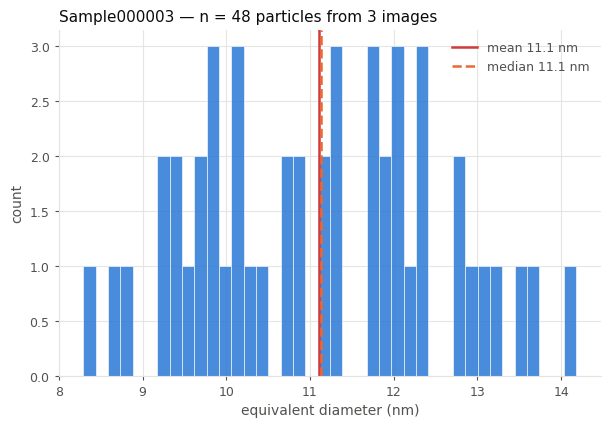

In [6]:
# Two calls: run the sizing for one sample, then draw the result.
# A plot never runs an analysis itself.
sizing = wb.run("particle_sizing", "Sample000003")
wb.plot_sizes(sizing)
plt.show()

Mean and median are both drawn because they disagree whenever
unseparated clusters survive into the tail — the gap between them is the signal
that they did.

Sizes are in **nanometres only when the file says so**. The demo writes a pixel
calibration into the TIFF description, the same way electron microscopes do;
without one, diameters come back in pixels with `calibrated: False` rather than
being silently mislabelled.

In [7]:
print("calibrated:", sizes["calibrated"].tolist())
result = wb.run("particle_sizing", "Sample000003")
print("nm per pixel:", result.diagnostics["nm_per_pixel_min"])

calibrated: [True, True, True, True, True, True]
nm per pixel: 0.5


## Save so the derived columns persist

In [8]:
wb.save()
sorted({name for s in wb.project for name in s.derived})

['tem_d_cv',
 'tem_d_mean',
 'tem_d_median',
 'tem_d_p10',
 'tem_d_p90',
 'tem_d_std',
 'tem_n_images',
 'tem_n_particles',
 'uvvis_baseline',
 'uvvis_fit_r2',
 'uvvis_peak1_amplitude',
 'uvvis_peak1_center',
 'uvvis_peak1_width']